# Political Bias Classification: Preprocessing + Fast Baselines


This notebook isolates the data preprocessing pipeline for the SemEval-2019 hyperpartisan news dataset and adds fast baseline classifiers. It is intentionally lightweight so it can run before the heavier BERT/RoBERTa experiments.

## 1. Install and Import Libraries

Run this in Google Colab. The dataset is loaded from Hugging Face, while preprocessing uses NLTK and the baseline models use scikit-learn.

In [ ]:
!pip -q install "datasets<3.0.0" nltk scikit-learn pandas matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [ ]:
import os
import re
import string
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset, concatenate_datasets
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 2. Configuration


In [ ]:
SEED = 42
DATASET_NAME = "SemEvalWorkshop/hyperpartisan_news_detection"
DATASET_CONFIG = "bypublisher"

TRAIN_PER_CLASS = 4000
VAL_PER_CLASS = 800

TEXT_COL = "text"
TITLE_COL = "title"
LABEL_COL = "bias"

LABEL_NAMES = ["right", "right-center", "least-biased", "left-center", "left"]
ID_TO_LABEL = dict(enumerate(LABEL_NAMES))
LABEL_TO_ID = {name: i for i, name in ID_TO_LABEL.items()}

OUTPUT_DIR = "chethas_preprocessing_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)

## 3. Load Dataset and Select Useful Fields



In [ ]:
dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG,
    trust_remote_code=True
)

dataset

Generating train split:   0%|          | 0/600000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/150000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias'],
        num_rows: 600000
    })
    validation: Dataset({
        features: ['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias'],
        num_rows: 150000
    })
})

In [ ]:
def subsample_stratified(split, n_per_class, label_col=LABEL_COL, seed=SEED):
    """Return a shuffled, class-balanced subset with up to n_per_class rows per label."""
    subsets = []
    for label in range(len(LABEL_NAMES)):
        subset = split.filter(lambda x, label=label: x[label_col] == label)
        subset = subset.shuffle(seed=seed)
        subset = subset.select(range(min(n_per_class, len(subset))))
        subsets.append(subset)
    return concatenate_datasets(subsets).shuffle(seed=seed)

train_raw = subsample_stratified(dataset["train"], TRAIN_PER_CLASS)
val_raw = subsample_stratified(dataset["validation"], VAL_PER_CLASS)

print(train_raw)
print(val_raw)
print(train_raw.column_names)

Filter:   0%|          | 0/600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/600000 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias'],
    num_rows: 20000
})
Dataset({
    features: ['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias'],
    num_rows: 4000
})
['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias']


In [ ]:
def keep_needed_fields(ds):
    return ds.select_columns([TITLE_COL, TEXT_COL, LABEL_COL])

train_raw = keep_needed_fields(train_raw)
val_raw = keep_needed_fields(val_raw)

train_df = train_raw.to_pandas()
val_df = val_raw.to_pandas()

train_df.head()

,title,text,bias
0,Presumed guilty,"<p>Not long ago, my wife Helms and I were havi...",3
1,A Judge Just Sentenced the Millionaire Montana...,<p>Gianforte pleaded guilty on Monday to assau...,4
2,More bodies found in Mexican grave,<p>.......... .......... .......... .............,2
3,Primary Campaigns Coming to the Finish Line,<p>.......... .......... .......... .............,2
4,Bush Poaches a Longtime Clinton Backer,<p>Lynne Sladky/AP</p> \n\n<p /> \n\n<p>The bi...,4


## 4. Quick Data Check


In [ ]:
def summarize_split(df, split_name):
    print(f"{split_name} shape:", df.shape)
    print("Missing values:")
    print(df.isna().sum())
    print("\nDuplicate article texts:", df[TEXT_COL].duplicated().sum())
    print("\nLabel counts:")
    print(df[LABEL_COL].map(ID_TO_LABEL).value_counts().sort_index())

summarize_split(train_df, "Train")
print("\n" + "=" * 50 + "\n")
summarize_split(val_df, "Validation")

Train shape: (20000, 3)
Missing values:
title    0
text     0
bias     0
dtype: int64

Duplicate article texts: 88

Label counts:
bias
least-biased    4000
left            4000
left-center     4000
right           4000
right-center    4000
Name: count, dtype: int64


Validation shape: (4000, 3)
Missing values:
title    0
text     0
bias     0
dtype: int64

Duplicate article texts: 18

Label counts:
bias
least-biased    800
left            800
left-center     800
right           800
right-center    800
Name: count, dtype: int64


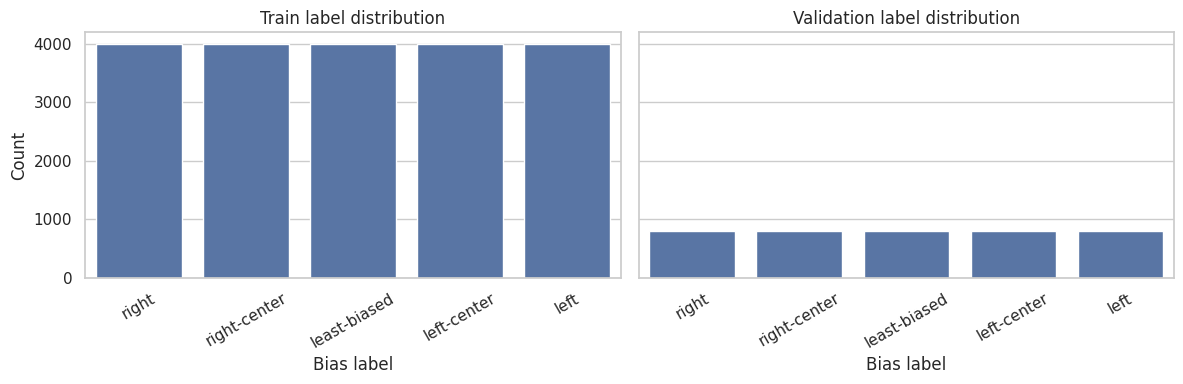

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, title in zip(axes, [train_df, val_df], ["Train", "Validation"]):
    counts = df[LABEL_COL].map(ID_TO_LABEL).value_counts().reindex(LABEL_NAMES)
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"{title} label distribution")
    ax.set_xlabel("Bias label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

## 5. Text Preprocessing


In [ ]:
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

HTML_RE = re.compile(r"<.*?>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_LETTER_RE = re.compile(r"[^a-zA-Z\s]")
WHITESPACE_RE = re.compile(r"\s+")

def combine_title_text(row):
    title = "" if pd.isna(row[TITLE_COL]) else str(row[TITLE_COL])
    text = "" if pd.isna(row[TEXT_COL]) else str(row[TEXT_COL])
    return f"{title}. {text}".strip()

def basic_normalize(text):
    """Remove HTML, URLs, punctuation, and numbers; lowercase; normalize whitespace."""
    text = str(text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.lower()
    text = NON_LETTER_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    normalized = basic_normalize(text)
    tokens = word_tokenize(normalized)

    if remove_stopwords:
        tokens = [tok for tok in tokens if tok not in STOP_WORDS]

    if lemmatize:
        tokens = [LEMMATIZER.lemmatize(tok) for tok in tokens]

    return " ".join(tokens)

def token_count(text):
    return len(str(text).split())

In [ ]:
sample_text = train_df.iloc[0][TEXT_COL]
print("Original sample:\n", sample_text[:700])
print("\nCleaned sample:\n", preprocess_text(sample_text)[:700])

Original sample:
 <p>Not long ago, my wife Helms and I were having one of those mornings where nothing is going quite right. We were late for everything, we weren&#8217;t getting things done, and to top it off, we had forgotten to grab our lunches from home in our haste to get out the door. As lunchtime approached, Helms expressed that on this particular day, food was not optional. There would be no unexpected fasting. So I ran out quickly to the nearby sandwich and coffee shop to grab a sandwich for her and a cup of coffee for myself. In keeping with the trend of the day, I ran out with the sandwich and left the full cup of coffee on the counter by mistake.</p> 

<p>I did not figure this out for some time. H

Cleaned sample:
 long ago wife helm one morning nothing going quite right late everything getting thing done top forgotten grab lunch home haste get door lunchtime approached helm expressed particular day food optional would unexpected fasting ran quickly nearby sandwich coffee s

## 6. Apply Preprocessing Pipeline


In [ ]:
def build_processed_df(df, split_name):
    processed = df.copy()
    processed["raw_text"] = processed.apply(combine_title_text, axis=1)
    processed["clean_text"] = processed["raw_text"].apply(preprocess_text)
    processed["label"] = processed[LABEL_COL].astype(int)
    processed["label_name"] = processed["label"].map(ID_TO_LABEL)
    processed["raw_word_count"] = processed["raw_text"].apply(token_count)
    processed["clean_word_count"] = processed["clean_text"].apply(token_count)
    processed["split"] = split_name
    return processed[["split", "title", "raw_text", "clean_text", "label", "label_name", "raw_word_count", "clean_word_count"]]

train_processed = build_processed_df(train_df, "train")
val_processed = build_processed_df(val_df, "validation")

train_processed.head()

,split,title,raw_text,clean_text,label,label_name,raw_word_count,clean_word_count
0,train,Presumed guilty,"Presumed guilty. <p>Not long ago, my wife Helm...",presumed guilty long ago wife helm one morning...,3,left-center,787,362
1,train,A Judge Just Sentenced the Millionaire Montana...,A Judge Just Sentenced the Millionaire Montana...,judge sentenced millionaire montana politician...,4,left,254,157
2,train,More bodies found in Mexican grave,More bodies found in Mexican grave. <p>..........,body found mexican grave mexico city number ex...,2,least-biased,193,95
3,train,Primary Campaigns Coming to the Finish Line,Primary Campaigns Coming to the Finish Line. <...,primary campaign coming finish line polling pl...,2,least-biased,447,277
4,train,Bush Poaches a Longtime Clinton Backer,Bush Poaches a Longtime Clinton Backer. <p>Lyn...,bush poaches longtime clinton backer lynne sla...,4,left,921,566


In [ ]:
length_summary = pd.concat([train_processed, val_processed]).groupby("split")[["raw_word_count", "clean_word_count"]].describe()
length_summary

raw_word_count                                                     \
                    count       mean          std  min    25%    50%     75%   
split                                                                          
train             20000.0   619.0654   772.709755  9.0  253.0  438.0   769.0   
validation         4000.0  1105.3595  1611.252541  4.0  260.0  564.5  1155.5   

                    clean_word_count                                     \
                max            count       mean         std  min    25%   
split                                                                     
train       33308.0          20000.0  351.04915  416.651300  6.0  148.0   
validation  25122.0           4000.0  612.70925  868.721061  3.0  145.0   

                                   
              50%    75%      max  
split                              
train       252.0  433.0  18786.0  
validation  312.0  642.0  13243.0

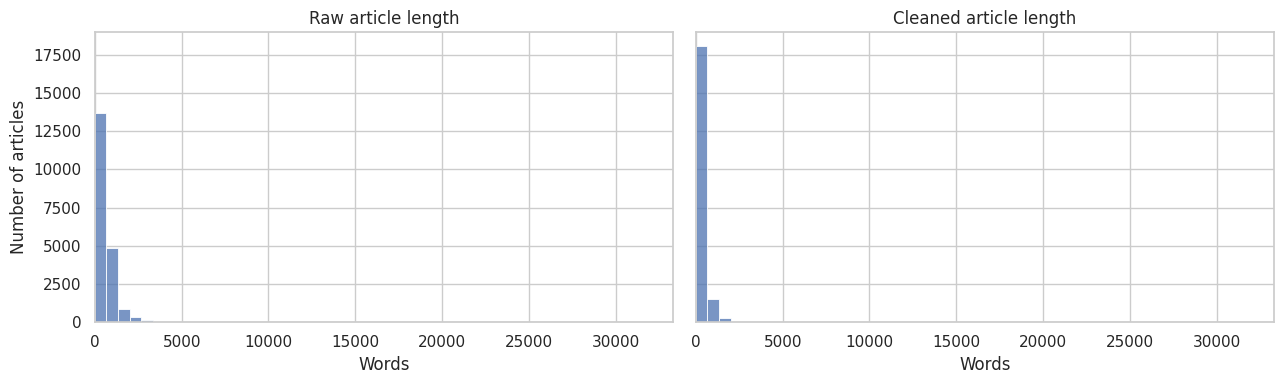

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

max_words = max(
    train_processed["raw_word_count"].max(),
    train_processed["clean_word_count"].max()
)

bins = np.linspace(0, max_words, 51)

sns.histplot(train_processed["raw_word_count"], bins=bins, ax=axes[0])
axes[0].set_title("Raw article length")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Number of articles")

sns.histplot(train_processed["clean_word_count"], bins=bins, ax=axes[1])
axes[1].set_title("Cleaned article length")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Number of articles")

for ax in axes:
    ax.set_xlim(0, max_words)

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")


Mounted at /content/gdrive


## 7. Save Processed Data


In [ ]:
OUTPUT_DIR = "/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_path = os.path.join(OUTPUT_DIR, "train_processed.csv")
val_path = os.path.join(OUTPUT_DIR, "val_processed.csv")
combined_path = os.path.join(OUTPUT_DIR, "combined_processed.csv")

train_processed.to_csv(train_path, index=False)
val_processed.to_csv(val_path, index=False)
pd.concat([train_processed, val_processed], ignore_index=True).to_csv(combined_path, index=False)

print(train_path)
print(val_path)
print(combined_path)


/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/train_processed.csv
/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/val_processed.csv
/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/combined_processed.csv


## 8. Prepare Baseline Inputs

The baseline models below are intentionally simple and fast. They give the project minimum comparison points before the transformer experiments.

In [ ]:
X_train_clean = train_processed["clean_text"]
X_val_clean = val_processed["clean_text"]
y_train = train_processed["label"]
y_val = val_processed["label"]

print(X_train_clean.shape, X_val_clean.shape)
print(Counter(y_train))

(20000,) (4000,)
Counter({3: 4000, 4: 4000, 2: 4000, 0: 4000, 1: 4000})


## 9. Majority Class Baseline

This is the minimum baseline: always predict the most frequent class. Since we sampled evenly, it should perform near random chance, but it is still useful as a sanity check.

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_clean, y_train)
dummy_preds = dummy.predict(X_val_clean)

print("Accuracy:", accuracy_score(y_val, dummy_preds))
print("Macro F1:", f1_score(y_val, dummy_preds, average="macro"))
print(classification_report(y_val, dummy_preds, target_names=LABEL_NAMES, zero_division=0))

Accuracy: 0.2
Macro F1: 0.06666666666666667
              precision    recall  f1-score   support

       right       0.20      1.00      0.33       800
right-center       0.00      0.00      0.00       800
least-biased       0.00      0.00      0.00       800
 left-center       0.00      0.00      0.00       800
        left       0.00      0.00      0.00       800

    accuracy                           0.20      4000
   macro avg       0.04      0.20      0.07      4000
weighted avg       0.04      0.20      0.07      4000



## 10. Fast Classical Baselines

These models should train quickly in Colab:

- TF-IDF + Logistic Regression
- TF-IDF + Linear SVM
- Bag-of-Words + Multinomial Naive Bayes

In [ ]:
models = {
    "tfidf_logistic_regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, max_df=0.9)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=SEED))
    ]),
    "tfidf_linear_svm": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, max_df=0.9)),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED))
    ]),
    "bow_multinomial_nb": Pipeline([
        ("bow", CountVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, max_df=0.9)),
        ("clf", MultinomialNB())
    ])
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_clean, y_train)
    preds = model.predict(X_val_clean)
    acc = accuracy_score(y_val, preds)
    macro = f1_score(y_val, preds, average="macro")
    results.append({"model": name, "accuracy": acc, "macro_f1": macro})
    trained_models[name] = model
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro:.4f}")
    print(classification_report(y_val, preds, target_names=LABEL_NAMES, zero_division=0))

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df


Training tfidf_logistic_regression...
Accuracy: 0.2717
Macro F1: 0.2464
              precision    recall  f1-score   support

       right       0.48      0.23      0.31       800
right-center       0.21      0.09      0.13       800
least-biased       0.32      0.13      0.19       800
 left-center       0.28      0.24      0.26       800
        left       0.24      0.67      0.35       800

    accuracy                           0.27      4000
   macro avg       0.31      0.27      0.25      4000
weighted avg       0.31      0.27      0.25      4000


Training tfidf_linear_svm...
Accuracy: 0.2850
Macro F1: 0.2667
              precision    recall  f1-score   support

       right       0.50      0.28      0.36       800
right-center       0.23      0.12      0.15       800
least-biased       0.33      0.14      0.20       800
 left-center       0.30      0.26      0.28       800
        left       0.24      0.63      0.34       800

    accuracy                           0.28     

,model,accuracy,macro_f1
1,tfidf_linear_svm,0.28500,0.266663
0,tfidf_logistic_regression,0.27175,0.246408
2,bow_multinomial_nb,0.23375,0.190437


## 11. Confusion Matrix for Best Baseline

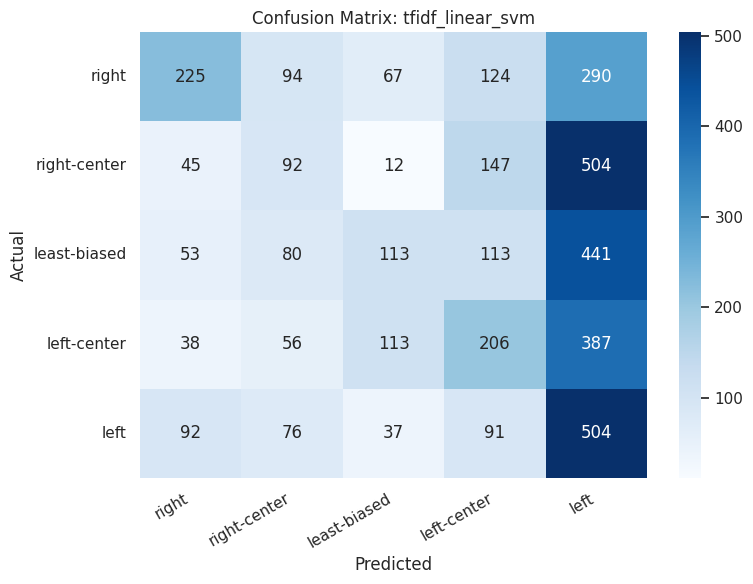

In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_val_clean)

cm = confusion_matrix(y_val, best_preds, labels=list(range(len(LABEL_NAMES))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Inspect Most Informative Logistic Regression Features

This helps connect the preprocessing and baseline work to error analysis/report writing. Coefficients are not causal explanations, but they show which TF-IDF features the linear model associates with each class.

In [ ]:
def show_top_logreg_features(model, label_names, top_n=20):
    vectorizer = model.named_steps["tfidf"]
    clf = model.named_steps["clf"]
    feature_names = np.array(vectorizer.get_feature_names_out())

    for label_id, label_name in enumerate(label_names):
        top_indices = np.argsort(clf.coef_[label_id])[-top_n:][::-1]
        print(f"\nTop features for {label_name}:")
        print(", ".join(feature_names[top_indices]))

if "tfidf_logistic_regression" in trained_models:
    show_top_logreg_features(trained_models["tfidf_logistic_regression"], LABEL_NAMES, top_n=20)


Top features for right:
continue reading, reading, continue, new window, open new, window, mr, hillary, open, share, leftist, nyse, com, advertisement, president trump, editing, click, obamacare, business, source

Top features for right-center:
upi, published time, read, apos, nevada, aug, president donald, published, nov, full article, film, embedded content, ethic public, read full, policy center, embedded, ethic, aug upi, public policy, season

Top features for least-biased:
advertisement, ap, albuquerque, new mexico, said, say, jan, santa fe, fe, mexico, amp amp, priest, journal, amp gt, santa, trust principle, gt, reuters trust, standard thomson, unm

Top features for left-center:
globalpost, baptist, amp, lgbt, say, nbc, california, according, church, globalpost amp, nbc news, blade, reported, chicago, washington blade, told nbc, pri, curwood, cnbc, pastor

Top features for left:
read, via, bush, mother jones, featured image, iraq, image via, like, href, lt href, worker, war, mo

## 13. Save Baseline Outputs

These files can be compared directly with the BERT/RoBERTa outputs later.

In [ ]:
results_path = os.path.join(OUTPUT_DIR, "baseline_results.csv")
preds_path = os.path.join(OUTPUT_DIR, f"preds_{best_model_name}.csv")
model_path = os.path.join(OUTPUT_DIR, f"{best_model_name}.joblib")

results_df.to_csv(results_path, index=False)
joblib.dump(best_model, model_path)

preds_df = val_processed[["title", "raw_text", "clean_text", "label", "label_name"]].copy()
preds_df["predicted"] = best_preds
preds_df["predicted_label"] = [ID_TO_LABEL[p] for p in best_preds]
preds_df.to_csv(preds_path, index=False)

print(results_path)
print(preds_path)
print(model_path)

/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/baseline_results.csv
/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/preds_tfidf_linear_svm.csv
/content/gdrive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/tfidf_linear_svm.joblib
